# Test Error vs. Training Set Size for d35_k3 Models

This notebook plots test error vs training set size for the three d35_k3_sig models (exp_0, exp_1, exp_2).


In [1]:
from pathlib import Path
import json
import sys
import importlib.util
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Import slim_plotters
def import_slim_plotters(slim_plotters_path: Optional[str] = None):
    """
    Try to import `slim_plotters` as a normal module. If that fails:
      - If slim_plotters_path is a directory, use <dir>/slim_plotters.py
      - If it's a file, import exactly that file.
    Returns: (apply, color, SciencePlotter, PlotStyle)
    """
    try:
        from slim_plotters import apply, color, SciencePlotter, PlotStyle
        return apply, color, SciencePlotter, PlotStyle
    except Exception:
        pass  # fallback below

    if slim_plotters_path is None:
        slim_plotters_path = "/home/goring/mean_field_langevin/plots_utils/slim_plotters.py"

    p = Path(slim_plotters_path).expanduser().resolve()
    if p.is_dir():
        p = p / "slim_plotters.py"
    if not p.exists():
        raise FileNotFoundError(f"slim_plotters.py not found at: {p}")

    # easiest: add its folder to sys.path then import
    sys.path.insert(0, str(p.parent))
    try:
        from slim_plotters import apply, color, SciencePlotter, PlotStyle
        return apply, color, SciencePlotter, PlotStyle
    except Exception:
        spec = importlib.util.spec_from_file_location("slim_plotters", str(p))
        if spec is None or spec.loader is None:
            raise ImportError(f"Could not load spec for: {p}")
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)
        sys.modules["slim_plotters"] = mod
        return mod.apply, mod.color, mod.SciencePlotter, mod.PlotStyle

# Import and apply slim_plotters
apply, color, SciencePlotter, PlotStyle = import_slim_plotters()
apply(theme="light")


In [ ]:
# Load training results from d35_k3_sig_full
model_results_path = Path("/home/goring/mean_field_langevin/Langevin_training/results_rebuttal/d35_k3_sig_full/d35_k3/training_results.json")
model_records = []

if model_results_path.exists():
    with model_results_path.open() as f:
        model_runs = json.load(f)
    
    # Load all results (no filtering by exp_id)
    for entry in model_runs:
        test_mse = entry.get("test_mse")
        if test_mse is not None:
            model_records.append({
                "P": entry.get("P"),
                "exp_id": entry.get("exp_id"),
                "test_mse": test_mse,
            })
else:
    raise FileNotFoundError(f"Training results not found at: {model_results_path}")

# Create DataFrame
model_df = pd.DataFrame(model_records)
print(f"Loaded {len(model_df)} records")
model_df.head()


Loaded 3 records


,P,exp_id,test_mse
0,10000,1,0.022977
1,10000,0,0.027433
2,10000,2,0.023790


In [3]:
# Aggregate by P
model_agg = (
    model_df
    .groupby("P", as_index=False)
    .agg(
        test_mse_mean=("test_mse", "mean"),
        test_mse_std=("test_mse", "std"),
        num_runs=("test_mse", "size"),
    )
    .sort_values("P")
)

# Calculate SEM (standard error of the mean) for error ribbons
model_agg["test_mse_sem"] = model_agg["test_mse_std"] / np.sqrt(model_agg["num_runs"])

model_agg


,P,test_mse_mean,test_mse_std,num_runs,test_mse_sem
0,10000,0.024733,0.002373,3,0.00137


Saved plot to: /home/goring/mean_field_langevin/plots/test_error_d35_k3.svg


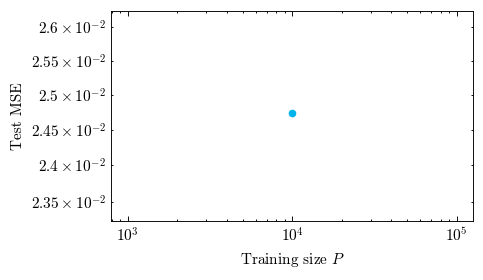

In [4]:
# Figure size matching fig1 style
fig_width = 4.5
aspect = 1.7
fig_h = fig_width / aspect
fig, ax = plt.subplots(figsize=(fig_width, fig_h))

# Prepare data
x = model_agg["P"].values
y_mean = model_agg["test_mse_mean"].values
y_sem = model_agg["test_mse_sem"].fillna(0.0).values

# Use a new blue color (similar to fig1 style)
line_color = "#01B5EB"  # Blue color from fig1

# Plot ribbon (filled area) with high alpha
ax.fill_between(
    x,
    y_mean - y_sem,
    y_mean + y_sem,
    alpha=0.4,
    color=line_color,
    edgecolor='none',
)

# Plot mean line
ax.plot(
    x,
    y_mean,
    marker="o",
    linestyle="-",
    color=line_color,
    markersize=4.0,
    linewidth=1.8,
    zorder=3,
)

# Axes styling matching fig1
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Training size $P$")
ax.set_ylabel(r"Test MSE")

# No grid, no title, no legend (matching fig1 style)
ax.grid(False)

plt.tight_layout()

# Save as SVG
output_path = Path("/home/goring/mean_field_langevin/plots/test_error_d35_k3.svg")
fig.savefig(output_path, format="svg", bbox_inches="tight")
print(f"Saved plot to: {output_path}")

plt.show()
